In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(1)
np.random.seed(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [8]:
n = 520
t = np.arange(n)
trend = 0.02 * t
seasonal_short = 1.2 * np.sin(2 * np.pi * t / 24)
seasonal_long = 0.9 * np.cos(2 * np.pi * t / 96)
regime = np.where(t > 320, 1.5, 0.0)
noise = np.random.normal(0, 0.35, size=n)
series = 20 + trend + seasonal_short + seasonal_long + regime + noise
df = pd.DataFrame({'time': t, 'value': series})
df['cycle_24_sin'] = np.sin(2 * np.pi * df['time'] / 24)
df['cycle_24_cos'] = np.cos(2 * np.pi * df['time'] / 24)
df['cycle_96_sin'] = np.sin(2 * np.pi * df['time'] / 96)
df['cycle_96_cos'] = np.cos(2 * np.pi * df['time'] / 96)

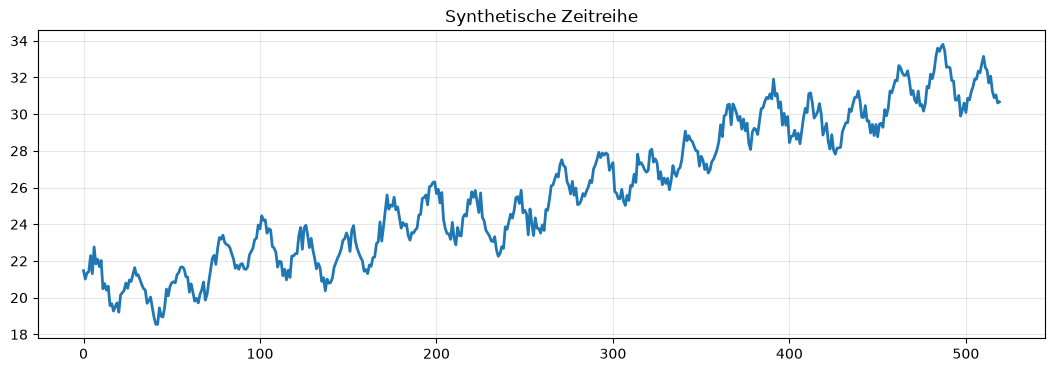

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['time'], df['value'], linewidth=2)
ax.set_title('Synthetische Zeitreihe')
ax.grid(True, alpha=0.3)
plt.show()


In [10]:
def make_windows(frame: pd.DataFrame, feature_cols: list[str], target_col: str, lookback: int, horizon: int):
    X, y = [], []
    for end in range(lookback, len(frame) - horizon + 1):
        X.append(frame.iloc[end - lookback:end][feature_cols].to_numpy(dtype=np.float32))
        y.append(frame.iloc[end:end + horizon][target_col].to_numpy(dtype=np.float32))
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

feature_cols = ['value', 'cycle_24_sin', 'cycle_24_cos', 'cycle_96_sin', 'cycle_96_cos']
LOOKBACK = 48
HORIZON = 12
X, y = make_windows(df, feature_cols=feature_cols, target_col='value', lookback=LOOKBACK, horizon=HORIZON)
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)
X_train, y_train = X[:train_end], y[:train_end]
X_test, y_test = X[val_end:], y[val_end:]

x_mean = X_train.mean(axis=(0, 1), keepdims=True)
x_std = X_train.std(axis=(0, 1), keepdims=True)
x_std = np.where(x_std == 0, 1, x_std)
y_mean, y_std = y_train.mean(), y_train.std()

def sx(a):
    return (a - x_mean) / x_std

def sy(a):
    return (a - y_mean) / y_std

train_ds = TensorDataset(torch.tensor(sx(X_train)), torch.tensor(sy(y_train)))
val_ds = TensorDataset(torch.tensor(sx(X_val)), torch.tensor(sy(y_val)))
test_x = torch.tensor(sx(X_test))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

NameError: name 'X_val' is not defined